In [13]:
import pandas as pd

df = pd.read_csv('../data/preprocessed/final_master_training_set.csv')

In [14]:


df = df[['text_features', 'classification']]
print(df.head())

                                       text_features   classification
0  Adaptation Platform Canada (2012) Strategic pl...  adaptation only
1  Canadian Agricultural Adaptation Program Canad...  adaptation only
2  Climate Change Adaptation Act Japan (2015) Pol...  adaptation only
3  Climate Ready States and Cities Initiative Uni...  adaptation only
4  Climate Ready Water Utilities (CRWU) United St...  adaptation only


In [15]:
#When creating a classifier we need to split our data into 
#training and test sets
#we train on a portion of the data and test on another portion of the data
#important that these samples are performed randomly 
train = df.sample(frac = 0.8)
test = df.drop(train.index)
print(train.shape)
print(test.shape)

(5455, 2)
(1364, 2)


In [16]:
#sklearn is a very large library
#therefore we typically import only the functions we are actually going to use
from sklearn.feature_extraction.text import CountVectorizer

#A 'vectorizer' turns text data into a numeric matrix
#which can then be used by the model
vectorizer = CountVectorizer()
train_vectors = vectorizer.fit_transform(train['text_features'])
test_vectors = vectorizer.transform(test['text_features'])
#nb diff between transform and fit transform

In [17]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
clf.fit(train_vectors, train['classification'])
test['pred'] = clf.predict(test_vectors)

In [18]:
test.head()

,text_features,classification,pred
2,Climate Change Adaptation Act Japan (2015) Pol...,adaptation only,adaptation only
5,Environmental Quality Incentives Program (EQIP...,adaptation only,mitigation only
7,FEMA Federal Flood Risk Management Standard Un...,adaptation only,mitigation only
10,National Climate Change Adaptation Plan France...,adaptation only,both
17,National Strategy for Climate Change Adaptatio...,adaptation only,adaptation only


In [19]:
#definitions can be found here: 
#https://medium.com/@shrutisaxena0617/precision-vs-recall-386cf9f89488
from sklearn import metrics
print(metrics.accuracy_score(test['classification'], test['pred']))
print(metrics.precision_score(test['classification'], test['pred'], average='macro'))
print(metrics.recall_score(test['classification'], test['pred'], average='macro'))

0.8936950146627566
0.7318448785800217
0.6394045341370724


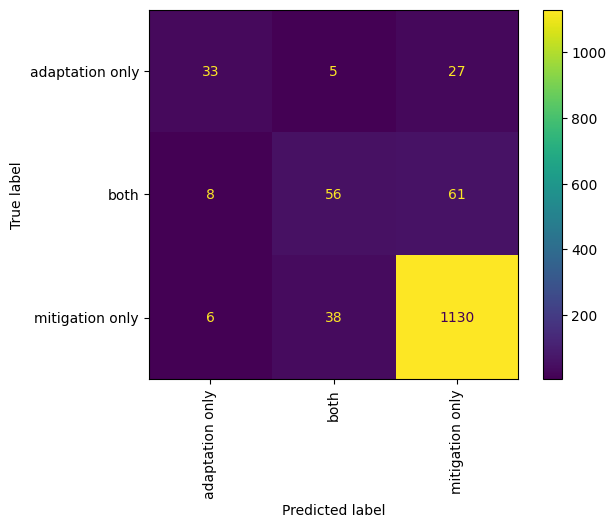

In [20]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test['classification'], test['pred'], labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=clf.classes_)
disp.plot(xticks_rotation = 'vertical')
plt.show()

In [21]:
# --- KNN TEST PREDICTOR ---
def test_knn_model(sample_text):
    # Transform text using the CountVectorizer from this notebook
    sample_vec = vectorizer.transform([sample_text])
    
    # Predict
    prediction = clf.predict(sample_vec)[0]
    
    # Get probabilities (if your KNN is configured for it)
    try:
        probs = clf.predict_proba(sample_vec)[0]
        conf = f"{max(probs)*100:.1f}%"
    except:
        conf = "N/A"
    
    print(f"--- KNN Prediction Results ---")
    print(f"Text: {sample_text[:100]}...")
    print(f"Label: {prediction}")
    print(f"Confidence: {conf}")

# Test it
test_string = "Implementing coastal barriers and sea walls to protect from rising sea levels."
test_knn_model(test_string)

--- KNN Prediction Results ---
Text: Implementing coastal barriers and sea walls to protect from rising sea levels....
Label: mitigation only
Confidence: 80.0%


In [22]:
# The 2026 Stress Test Suite
test_policies = [
    "Construction of regional seed banks to preserve indigenous crop varieties against increasing drought frequency.",
    "Mandatory retrofitting of industrial furnaces to utilize green hydrogen instead of liquid natural gas.",
    "Restoration of coastal mangrove forests to sequester carbon and provide natural storm surge protection.",
    "Upgrading the national railway grid to withstand extreme heat buckling while increasing electric cargo capacity.",
    "The Ministry of Environment issued a general executive decree regarding the 2013 planning framework for national development."
]

print(f"Model being tested: {type(clf).__name__}\n")

for i, policy in enumerate(test_policies):
    # Vectorize and Predict (Matches your specific notebook's vectorizer)
    vec = vectorizer.transform([policy])
    label = clf.predict(vec)[0]
    
    # Try to get probability for 'Confidence'
    try:
        prob = clf.predict_proba(vec).max()
        confidence = f"{prob:.2%}"
    except:
        confidence = "N/A"
        
    print(f"Test {i+1}: {label} ({confidence})")
    print(f"Text: {policy[:80]}...")
    print("-" * 20)

Model being tested: KNeighborsClassifier

Test 1: mitigation only (80.00%)
Text: Construction of regional seed banks to preserve indigenous crop varieties agains...
--------------------
Test 2: mitigation only (100.00%)
Text: Mandatory retrofitting of industrial furnaces to utilize green hydrogen instead ...
--------------------
Test 3: mitigation only (80.00%)
Text: Restoration of coastal mangrove forests to sequester carbon and provide natural ...
--------------------
Test 4: mitigation only (60.00%)
Text: Upgrading the national railway grid to withstand extreme heat buckling while inc...
--------------------
Test 5: adaptation only (40.00%)
Text: The Ministry of Environment issued a general executive decree regarding the 2013...
--------------------


In [23]:
import joblib

joblib.dump(clf, 'knn_model.joblib')
joblib.dump(vectorizer, 'knn_vectorizer.joblib')

['knn_vectorizer.joblib']